# 04. Подготовка COD и crystalDB

COD читается напрямую из исходного `cod_full.parquet`. Архив Materials Project
распаковывается в локально, после чего space group вычисляется.

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("неверный путь.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from project_paths import *
ensure_project_directories()

print("Project root:", PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [2]:
import subprocess

def run_script(script_name, *args):
    # Run one reproducible pipeline stage and stream its output.
    command = [sys.executable, str(PROJECT_ROOT / "src" / script_name), *map(str, args)]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

## Проверка структуры COD Parquet

In [ ]:
import pyarrow.parquet as pq
import gemmi

cod = pq.ParquetFile(RAW_SOURCES["cod_parquet"])
required = {"file", "cif_text", "sgNumber", "duplicateof"}

assert required.issubset(cod.schema_arrow.names)

print(f"COD rows: {cod.metadata.num_rows:,}; row groups: {cod.num_row_groups:,}")
display(cod.schema_arrow)

COD rows: 533,486; row groups: 54


file: int64
a: double
siga: double
b: double
sigb: double
c: double
sigc: double
alpha: double
sigalpha: double
beta: double
sigbeta: double
gamma: double
siggamma: double
vol: double
sigvol: double
celltemp: double
sigcelltemp: double
diffrtemp: double
sigdiffrtemp: double
cellpressure: double
sigcellpressure: double
diffrpressure: double
sigdiffrpressure: double
thermalhist: string
pressurehist: string
compoundsource: string
nel: string
sg: string
sgHall: string
sgNumber: int64
commonname: string
chemname: string
mineral: string
formula: string
calcformula: string
cellformula: string
Z: int64
Zprime: double
acce_code: string
authors: string
title: string
journal: string
year: int64
volume: int64
issue: string
firstpage: string
lastpage: string
doi: string
method: string
radiation: string
wavelength: double
radType: string
radSymbol: string
Rall: double
Robs: double
Rref: double
wRall: double
wRobs: double
wRref: double
RFsqd: double
RI: double
gofall: double
gofobs: double
gofgt: dou

## Контрольный разбор CIF

In [ ]:
table = cod.read_row_group(0, columns=["file", "cif_text"])
parsed = 0

for cif_text in table["cif_text"][:1000].to_pylist():
    try:
        block = gemmi.cif.read_string(cif_text).sole_block()
        gemmi.make_small_structure_from_block(block)
        parsed += 1

    except Exception:
        pass

print(f"Gemmi parsed {parsed}/1000 CIF records")

Gemmi parsed 1000/1000 CIF records


## Распаковка crystalDB

In [ ]:
import gzip
import shutil

mp_db = DATA_DIR / "MP.db"

if not mp_db.exists():
    with gzip.open(RAW_SOURCES["crystaldb_gzip"], "rb") as source:
        with mp_db.open("wb") as destination:
            shutil.copyfileobj(source, destination)
            
print(f"MP.db: {mp_db.stat().st_size / 1024**2:.1f} MiB")

MP.db: 238.2 MiB


## Вычисление space group для crystalDB

In [6]:
run_script("precompute_mp_sg.py", "--workers", "5", "--chunk", "300")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\precompute_mp_sg.py --workers 5 --chunk 300


## Распределения crystalDB

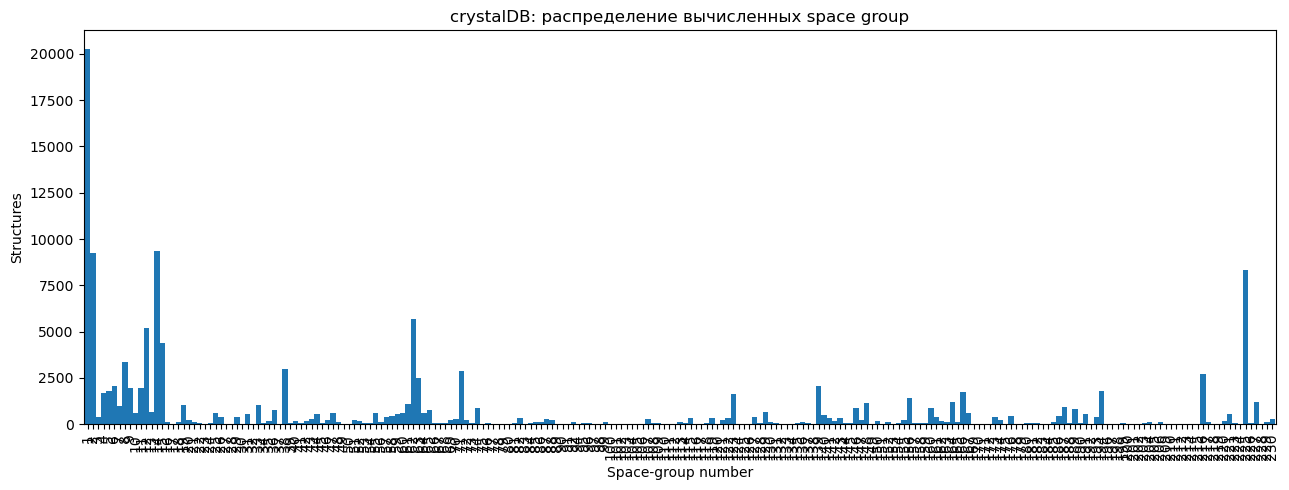

crystalDB structures: 135,258


In [ ]:
from ase.db import connect
import matplotlib.pyplot as plt
import pandas as pd

db = connect(str(DATA_DIR / "MP.db"))
sg = pd.read_csv(DATA_DIR / "mp_sg.csv")

fig, ax = plt.subplots(figsize=(13, 5))

sg.loc[sg["status"].eq("ok"), "sg"].value_counts().sort_index().plot.bar(ax=ax, width=1)

ax.set_title("crystalDB: распределение вычисленных space group")
ax.set_xlabel("Space-group number")
ax.set_ylabel("Structures")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_crystaldb_spacegroups.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"crystalDB structures: {len(db):,}")

## Вывод

Оба источника структур готовы для физической генерации синтетических спектров.